In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import json
from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize

from model import (
    Params,
    ArtificialNN
)
import utils

# Bootstrap supervised learning

Epoch    1/300, loss=0.892950
Epoch   10/300, loss=0.092980
Epoch   20/300, loss=0.059675
Epoch   30/300, loss=0.047390
Epoch   40/300, loss=0.040890
Epoch   50/300, loss=0.035980
Epoch   60/300, loss=0.033490
Epoch   70/300, loss=0.030919
Epoch   80/300, loss=0.029289
Epoch   90/300, loss=0.027718
Epoch  100/300, loss=0.026581
Epoch  107/300, loss=0.016046 [early stopping]


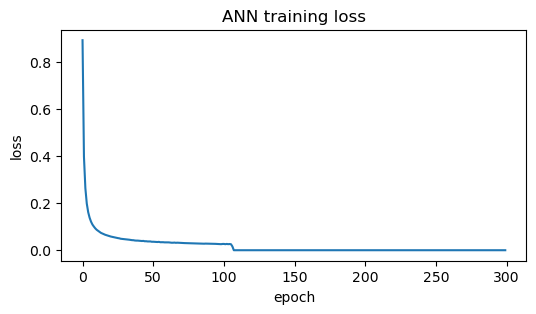

In [12]:
p = Params()
c_min = 0
c_max = 1
neighborhood_size_min = 0
neighborhood_size_max = 4

# 1) Generate a random dataset + label rule-based
X, y = utils.generate_random_ann_dataset(
    p=p,
    n_samples=30000,
    rng_seed=42,
    oxygen_min=c_min,
    oxygen_max=c_max,
    n_neighbors_min=neighborhood_size_min,
    n_neighbors_max=neighborhood_size_max,
)

# 2) Train the ANN starting with default parametrs values for w, W, theta, phi
ann = ArtificialNN()
history = ann.fit(
    X=X,
    y=y,
    lr=0.07,
    epochs=300,
    batch_size=32,
    rng_seed=42,
    verbose=True,
    early_stopping=True,
    es_count_max=10,
    es_threshold=0.0005
)

# 3) Plot the curve of the loss
plt.figure(figsize=(6, 3))
plt.plot(history["loss"])
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("ANN training loss")
plt.show()


In [13]:
ann_params = {
    "w": ann.w_in_hidden.tolist(),
    "W": ann.W_hidden_out.tolist(),
    "theta": ann.theta_hidden.tolist(),
    "phi": ann.phi_out.tolist(),
    "output_order": list(ann.output_raw_order),
}
ann_params

{'w': [[3.2660470008850098, 0.08729133754968643],
  [0.09105804562568665, 4.666468620300293],
  [0.03274819254875183, -16.454641342163086]],
 'W': [[0.01088994275778532, -3.610659599304199, 10.733226776123047],
  [-8.830424308776855, 3.5163583755493164, -8.390685081481934],
  [8.016100883483887, -0.20753882825374603, -8.362018585205078]],
 'theta': [8.164213180541992, 0.5017130374908447, -2.301950454711914],
 'phi': [2.5047755241394043, -1.6086006164550781, 3.6782689094543457],
 'output_order': ['A', 'P', 'Q']}

# Testing

### Generate random dataset

In [14]:
X_test, y_test = utils.generate_random_ann_dataset(
    p=p,
    n_samples=10000,
    rng_seed=123,
    oxygen_min=0.0,
    oxygen_max=1.0,
    n_neighbors_min=0,
    n_neighbors_max=4,
)

class_names = ["P", "Q", "A"]  # y mapping: 0=P, 1=Q, 2=A
classes = [0, 1, 2]
print("Classes test distribution:", {class_names[i]: int(np.sum(y_test == i)) for i in classes})


Classes test distribution: {'P': 5073, 'Q': 3404, 'A': 1523}


### Predictions

In [15]:
proba = np.zeros((X_test.shape[0], 3), dtype=np.float32)  # [P, Q, A]
for i, (c_val, n_val) in enumerate(X_test):
    proba[i] = ann.forward(float(c_val), int(n_val))
y_pred = np.argmax(proba, axis=1)


### Basic metrics

In [16]:
acc = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")
f1_per_class = f1_score(y_test, y_pred, average=None, labels=classes)

print(f"Accuracy           : {acc:.4f}")
print(f"Balanced Accuracy  : {bacc:.4f}")
print(f"F1 macro           : {f1_macro:.4f}")
print(f"F1 weighted        : {f1_weighted:.4f}")
for i, cname in enumerate(class_names):
    print(f"F1 {cname:<2}              : {f1_per_class[i]:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))


Accuracy           : 0.9994
Balanced Accuracy  : 0.9987
F1 macro           : 0.9991
F1 weighted        : 0.9994
F1 P               : 0.9996
F1 Q               : 0.9997
F1 A               : 0.9980

Classification report:
              precision    recall  f1-score   support

           P     0.9992    1.0000    0.9996      5073
           Q     0.9994    1.0000    0.9997      3404
           A     1.0000    0.9961    0.9980      1523

    accuracy                         0.9994     10000
   macro avg     0.9995    0.9987    0.9991     10000
weighted avg     0.9994    0.9994    0.9994     10000



### Confusion matrix

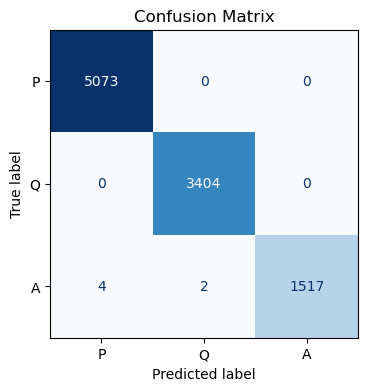

In [17]:
cm = confusion_matrix(y_test, y_pred, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix")
plt.show()


### ROC curve

ROC AUC macro (OvR)    : 1.0000
ROC AUC weighted (OvR) : 1.0000


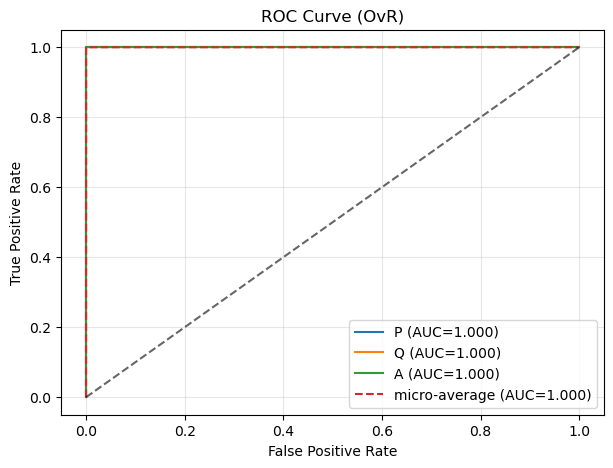

In [18]:
y_test_bin = label_binarize(y_test, classes=classes)  # shape (N,3)

auc_macro_ovr = roc_auc_score(y_test_bin, proba, multi_class="ovr", average="macro")
auc_weighted_ovr = roc_auc_score(y_test_bin, proba, multi_class="ovr", average="weighted")

print(f"ROC AUC macro (OvR)    : {auc_macro_ovr:.4f}")
print(f"ROC AUC weighted (OvR) : {auc_weighted_ovr:.4f}")

# ROC curves per classe
plt.figure(figsize=(7, 5))
for k, cname in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, k], proba[:, k])
    roc_auc_k = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cname} (AUC={roc_auc_k:.3f})")

# micro-average ROC
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), proba.ravel())
auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle="--", label=f"micro-average (AUC={auc_micro:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (OvR)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ANN decision map

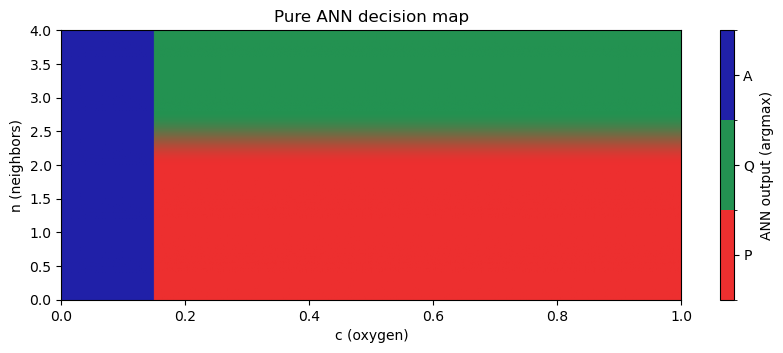

In [19]:
# Pure ANN predictions (no oxygen demand / necrosis / extra rules)
ann = ArtificialNN(ann_params)
c_values = np.linspace(c_min, c_max, 401)
n_values = np.arange(neighborhood_size_min, neighborhood_size_max + 1, dtype=int)

# rows -> neighbors (n), cols -> oxygen (c), values: 0=P, 1=Q, 2=A
predictions = np.zeros((len(n_values), len(c_values)), dtype=np.int8)

for i, n in enumerate(n_values):
    for j, c in enumerate(c_values):
        scores = ann.forward(float(c), int(n))
        predictions[i, j] = int(np.argmax(scores))

# Plot ANN decision map
plt.figure(figsize=(10, 3.5))
im = plt.imshow(
    predictions,
    origin="lower",
    aspect="auto",
    extent=[c_min, c_max, neighborhood_size_min, neighborhood_size_max],
)

decision_cmap = ListedColormap(["#ed2f2f", "#239251", "#2020a8"])  # P, Q, A
decision_norm = BoundaryNorm(np.arange(-0.5, 3.5, 1.0), decision_cmap.N)
im.set_cmap(decision_cmap)
im.set_norm(decision_norm)

cbar = plt.colorbar(im, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["P", "Q", "A"])
cbar.set_label("ANN output (argmax)")

plt.xlabel("c (oxygen)")
plt.ylabel("n (neighbors)")
plt.title("Pure ANN decision map")
plt.show()

# Save parameters

In [20]:
def _to_serializable(x):
        if isinstance(x, np.ndarray):
            return x.tolist()
        return x

filepath = '.env_ann_params'
payload = {
    "w": _to_serializable(ann_params["w"]),
    "W": _to_serializable(ann_params["W"]),   # evito collisione con ANN_W
    "theta": _to_serializable(ann_params["theta"]),
    "phi": _to_serializable(ann_params["phi"]),
    "output_order": _to_serializable(ann_params.get("output_order", ["A", "P", "Q"])),
}

lines = [f'{k}={json.dumps(v, separators=(",", ":"))}' for k, v in payload.items()]
Path(filepath).write_text("\n".join(lines) + "\n", encoding="utf-8")

465